<a href="https://colab.research.google.com/github/crystalle77/4250proj/blob/main/Reports.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

In [14]:
import pandas as pd
import re

ALL_TRANSACTIONS_FILE = "All_Transaction_Tech_2026-04-20_2026-05-06 1(Transactions).csv"
LODGING_FILE = "Lodging_Tax_Details_2026-04-20_to_2026-05-06.xlsx"

OUTPUT_FILE = "mergedTransactionFile_FIXED.xlsx"
GAPS_FILE = "missingItemGapsByDate_FIXED.xlsx"

# =====================================================
# HELPERS
# =====================================================

def clean_text(x):
    if pd.isna(x):
        return ""
    return re.sub(r"\s+", " ", str(x).strip().lower())

def clean_reference(x):
    x = clean_text(x)
    x = x.replace("fee for ", "")
    x = x.replace(" refund", "")
    return clean_text(x)

def clean_product(x):
    x = clean_text(x)

    # Remove parenthetical details like:
    # fountain drink (l)
    # propane (5 gallons)
    # rental charges (20/04 - 21/04)
    x = re.sub(r"\([^)]*\)", "", x)

    # Remove date range suffixes like:
    # - 22 apr to 20 may 2026
    x = re.sub(
        r"\s*-\s*\d{1,2}\s+[a-z]{3}\s+to\s+\d{1,2}\s+[a-z]{3}\s+\d{4}",
        "",
        x
    )

    return clean_text(x)

def find_col(df, options):
    for col in df.columns:
        c = clean_text(col)
        for option in options:
            if option in c:
                return col
    raise Exception(f"Could not find column matching: {options}")

# =====================================================
# LOAD FILES
# =====================================================

all_txn = pd.read_csv(
    ALL_TRANSACTIONS_FILE,
    header=5,
    encoding='latin1' # Added encoding
)

lodging = pd.read_excel(LODGING_FILE)

all_txn.columns = [str(c).strip() for c in all_txn.columns]
lodging.columns = [str(c).strip() for c in lodging.columns]

# =====================================================
# IDENTIFY COLUMNS
# =====================================================

all_ref_col = find_col(all_txn, ["reference"])
all_date_col = find_col(all_txn, ["date"])
all_product_col = find_col(all_txn, ["product", "item"])

lodging_ref_col = find_col(lodging, ["reference"])
lodging_date_col = find_col(lodging, ["date"])
lodging_product_col = find_col(lodging, ["product", "item"])

# =====================================================
# CLEAN ALL TRANSACTIONS BEFORE MERGE
# =====================================================

all_txn[all_ref_col] = all_txn[all_ref_col].ffill()
all_txn["base_reference"] = all_txn[all_ref_col].apply(clean_reference)
all_txn["base_product"] = all_txn[all_product_col].apply(clean_product)

all_txn[all_date_col] = pd.to_datetime(
    all_txn[all_date_col],
    errors="coerce"
)

# Fill date across same reference BEFORE merging
all_txn["date"] = (
    all_txn
    .groupby("base_reference")[all_date_col]
    .transform(lambda x: x.ffill().bfill())
)

# Fill payment/order fields across same reference
for col in ["Payment Type", "Order Total"]:
    if col in all_txn.columns:
        all_txn[col] = (
            all_txn
            .groupby("base_reference")[col]
            .transform(lambda x: x.ffill().bfill())
        )

# =====================================================
# CLEAN LODGING BEFORE MERGE
# =====================================================

lodging[lodging_ref_col] = lodging[lodging_ref_col].ffill()
lodging["base_reference"] = lodging[lodging_ref_col].apply(clean_reference)
lodging["base_product"] = lodging[lodging_product_col].apply(clean_product)

lodging[lodging_date_col] = pd.to_datetime(
    lodging[lodging_date_col],
    errors="coerce"
)

lodging["date"] = (
    lodging
    .groupby("base_reference")[lodging_date_col]
    .transform(lambda x: x.ffill().bfill())
)

# =====================================================
# PREPARE MERGE DATA
# =====================================================

all_merge = all_txn[[
    "date",
    all_ref_col,
    all_product_col,
    "base_reference",
    "base_product",
    "Qty",
    "Line Total",
    "Payment Type",
    "Order Total"
]].copy()

all_merge.rename(columns={
    all_ref_col: "transaction_reference",
    all_product_col: "transaction_product",
    "Qty": "txn_qty",
    "Line Total": "txn_line_total",
    "Payment Type": "payment_type",
    "Order Total": "txn_order_total"
}, inplace=True)

all_merge["in_all_transactions"] = True

lodging_merge = lodging[[
    "date",
    lodging_ref_col,
    lodging_product_col,
    "base_reference",
    "base_product",
    "Customer",
    "Total Sales (Col 1)",
    "Sales Not Taxed (Col 2)",
    "Tax Exempt Sales (Col 3)",
    "Net Taxable Sales (Col 4)",
    "Tax 5%",
    "Tax 10%",
    "Tax Total",
    "Total + Taxes",
    "Order Total"
]].copy()

lodging_merge.rename(columns={
    lodging_ref_col: "lodging_reference",
    lodging_product_col: "lodging_product",
    "Customer": "lodging_customer",
    "Total Sales (Col 1)": "lodging_total_sales",
    "Sales Not Taxed (Col 2)": "lodging_sales_not_taxed",
    "Tax Exempt Sales (Col 3)": "lodging_tax_exempt_sales",
    "Net Taxable Sales (Col 4)": "lodging_net_taxable_sales",
    "Tax 5%": "tax_5_percent",
    "Tax 10%": "tax_10_percent",
    "Tax Total": "lodging_tax_total",
    "Total + Taxes": "total_plus_taxes",
    "Order Total": "lodging_order_total"
}, inplace=True)

lodging_merge["in_lodging_report"] = True

# =====================================================
# MERGE ON CLEANED REFERENCE + CLEANED PRODUCT
# =====================================================

combined = pd.merge(
    all_merge,
    lodging_merge,
    on=["base_reference", "base_product"],
    how="outer",
    suffixes=("_txn", "_lodging")
)

# Final date: take transaction date first, lodging date second
combined["date"] = combined["date_txn"].fillna(combined["date_lodging"])

# Emergency final fill by base_reference
combined["date"] = (
    combined
    .groupby("base_reference")["date"]
    .transform(lambda x: x.ffill().bfill())
)

combined["reference"] = combined["transaction_reference"].fillna(combined["lodging_reference"])
combined["product"] = combined["transaction_product"].fillna(combined["lodging_product"])

combined["in_all_transactions"] = combined["in_all_transactions"].fillna(False)
combined["in_lodging_report"] = combined["in_lodging_report"].fillna(False)

combined["missing_in_lodging"] = ~combined["in_lodging_report"]
combined["missing_in_transactions"] = ~combined["in_all_transactions"]

# Fill blanks
num_cols = [
    "txn_qty", "txn_line_total", "txn_order_total",
    "lodging_total_sales", "lodging_sales_not_taxed",
    "lodging_tax_exempt_sales", "lodging_net_taxable_sales",
    "tax_5_percent", "tax_10_percent",
    "lodging_tax_total", "total_plus_taxes",
    "lodging_order_total"
]

for col in num_cols:
    if col in combined.columns:
        combined[col] = combined[col].fillna(0)

# =====================================================
# PRODUCT CATEGORIZATION
# =====================================================

def get_product_category(base_product):
    product_lower = str(base_product).lower()

    # Rule 1: Facility Fees
    keywords_fac_fee = ["facility fees"]
    if any(keyword in product_lower for keyword in keywords_fac_fee):
        return "Facility Fee GL List"
    # Rule 2: Camp Site Rental Charges
    keywords_camp_ground_fee = ["camp site", "rental charges"]
    # Check if all keywords are present to ensure it's a 'camp site rental charges' product
    if all(keyword in product_lower for keyword in keywords_camp_ground_fee):
        return "Camp Ground Fee GL List"
    # Rule 3: Lodging Tax Discount / Discount
    keywords_lodging_tax = ["lodging tax discount", "discount"]
    if any(keyword in product_lower for keyword in keywords_lodging_tax):
        return "Lodging Tax Fee List"
    # Rule 4: Laundry
    keywords_laundry = ["laundry"]
    if any(keyword in product_lower for keyword in keywords_laundry):
        return "Laundry List"
    # Rule 5: Everything else goes to Grocery List
    return "Grocery List"

combined["product_category"] = combined["base_product"].apply(get_product_category)


# =====================================================
# STATUS LOGIC
# =====================================================

def determine_status(row):
    product_lower = str(row["base_product"]).lower()
    payment_type_lower = str(row.get("payment_type", "")).strip().lower()

    is_campground_product = any(k in product_lower for k in [
        "camp ground",
        "camp site",
        "campsite",
        "facility fee",
        "facility fees",
        "rental charges"
    ])

    if row["missing_in_lodging"] and is_campground_product:
        return "addToBreakdown"

    if row["missing_in_transactions"] and "manual" in payment_type_lower:
        return "addToTill"

    return "everythingElse"

combined["status"] = combined.apply(determine_status, axis=1)

# =====================================================
# FINAL OUTPUT
# =====================================================

final_cols = [
    "date",
    "reference",
    "product",
    "base_reference",
    "base_product",
    "product_category", # Added new column
    "txn_qty",
    "txn_line_total",
    "payment_type",
    "txn_order_total",
    "lodging_customer",
    "lodging_total_sales",
    "lodging_sales_not_taxed",
    "lodging_tax_exempt_sales",
    "lodging_net_taxable_sales",
    "tax_5_percent",
    "tax_10_percent",
    "lodging_tax_total",
    "total_plus_taxes",
    "lodging_order_total",
    "in_all_transactions",
    "in_lodging_report",
    "missing_in_lodging",
    "missing_in_transactions",
    "status"
]

final_df = combined[final_cols].copy()

final_df["date"] = pd.to_datetime(final_df["date"], errors="coerce").dt.strftime("%Y-%m-%d")

final_df = final_df.sort_values(
    by=["date", "base_reference", "base_product"],
    na_position="last"
).reset_index(drop=True)

gaps_df = final_df[
    (final_df["missing_in_lodging"] == True) |
    (final_df["missing_in_transactions"] == True)
].copy()

summary_df = (
    gaps_df
    .groupby(["date", "status"])
    .size()
    .reset_index(name="count")
    .sort_values(["date", "status"])
)

no_date_df = final_df[
    final_df["date"].isna() | (final_df["date"] == "NaT")
].copy()

with pd.ExcelWriter(OUTPUT_FILE, engine="openpyxl") as writer:
    final_df.to_excel(writer, sheet_name="Full Reconciliation", index=False)
    gaps_df.to_excel(writer, sheet_name="Only Gaps", index=False)
    summary_df.to_excel(writer, sheet_name="Summary", index=False)
    no_date_df.to_excel(writer, sheet_name="Rows Still Missing Date", index=False)

with pd.ExcelWriter(GAPS_FILE, engine="openpyxl") as writer:
    gaps_df.to_excel(writer, sheet_name="Gaps Report with Status", index=False)
    summary_df.to_excel(writer, sheet_name="Summary by Date Status", index=False)
    no_date_df.to_excel(writer, sheet_name="Rows Still Missing Date", index=False)

print("DONE")
print("Main output:", OUTPUT_FILE)
print("Gaps output:", GAPS_FILE)
print("Rows still missing date:", len(no_date_df))

/tmp/ipykernel_7764/421049627.py:214: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  combined["in_all_transactions"] = combined["in_all_transactions"].fillna(False)
/tmp/ipykernel_7764/421049627.py:215: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  combined["in_lodging_report"] = combined["in_lodging_report"].fillna(False)


DONE
Main output: mergedTransactionFile_FIXED.xlsx
Gaps output: missingItemGapsByDate_FIXED.xlsx
Rows still missing date: 160


In [15]:
import pandas as pd

# The previous cell generates an XLSX file, not a CSV.
MERGED_FILE = "mergedTransactionFile_FIXED.xlsx"

try:
    # Use pd.read_excel() to read the XLSX file
    merged_df = pd.read_excel(MERGED_FILE)
except FileNotFoundError:
    print(f"Error: The file '{MERGED_FILE}' was not found. Please ensure the previous cell was run and generated the correct XLSX file.")
    # Assign an empty DataFrame to avoid NameError in subsequent operations if the file is not found
    merged_df = pd.DataFrame()

# =========================================================
# CLEAN REFERENCES
# =========================================================

merged_df["reference"] = (
    merged_df["reference"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Create normalized/base reference
merged_df["base_reference"] = (
    merged_df["reference"]
    .str.replace("refund", "", regex=False)
    .str.replace("fee for ", "", regex=False)
    .str.replace("fee for", "", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# =========================================================
# CLEAN DATE COLUMN
# =========================================================

merged_df["date"] = merged_df["date"].replace(
    ["", " ", "nan", "NaT", None],
    pd.NA
)

merged_df["date"] = pd.to_datetime(
    merged_df["date"],
    errors="coerce"
)

# =========================================================
# FILL DATES USING BASE REFERENCE
# =========================================================

merged_df["date"] = (
    merged_df
    .groupby("base_reference")["date"]
    .transform(lambda x: x.ffill().bfill())
)

# =========================================================
# FILTER FOR MISSING ITEMS
# =========================================================

missing_items_df = merged_df[
    (merged_df["missing_in_lodging"] == True) |
    (merged_df["missing_in_transactions"] == True)
].copy()

if missing_items_df.empty:
    print("No missing transactions found by item in either report.")
else:
    def determine_status(row):
        product_lower = str(row["product"]).lower()

        is_campground_fee_product = any(
            keyword in product_lower
            for keyword in [
                "camp ground",
                "camp site",
                "campsite",
                "facility fees",
                "facility fee"
            ]
        )

        payment_type_lower = ""
        if pd.notna(row["payment_type"]):
            payment_type_lower = str(row["payment_type"]).strip().lower()

        if row["missing_in_lodging"] and is_campground_fee_product:
            return "addToBreakdown"

        elif row["missing_in_transactions"] and payment_type_lower == "manual":
            return "addToTill"

        else:
            return "everythingElse"

    missing_items_df["status"] = missing_items_df.apply(determine_status, axis=1)

    summary_by_status_date = (
        missing_items_df
        .groupby(["date", "status"])
        .size()
        .reset_index(name="count")
        .sort_values(["date", "status"])
    )

    print("\nSummary of Missing Items by Date and Status:")
    display(summary_by_status_date)

    print("\nMissing Items with Status:")
    display(missing_items_df[[
        "date",
        "reference",
        "product",
        "payment_type",
        "missing_in_lodging",
        "missing_in_transactions",
        "status"
    ]].head())

    OUTPUT_GAPS_FILE = "missingItemGapsByDate.xlsx" # Outputting to XLSX is fine as requested before

    with pd.ExcelWriter(OUTPUT_GAPS_FILE, engine="openpyxl") as writer:
        missing_items_df.to_excel(
            writer,
            sheet_name="Gaps Report with Status",
            index=False
        )

        summary_by_status_date.to_excel(
            writer,
            sheet_name="Summary by Date Status",
            index=False
        )

    print(f"\nDetailed gaps report with status saved to: {OUTPUT_GAPS_FILE}")


Summary of Missing Items by Date and Status:


,date,status,count
0,2026-04-20,addToBreakdown,3
1,2026-04-20,everythingElse,13
2,2026-04-21,addToBreakdown,2
3,2026-04-21,everythingElse,8
4,2026-04-22,everythingElse,10
5,2026-04-23,addToBreakdown,2
6,2026-04-23,everythingElse,10
7,2026-04-24,everythingElse,8
8,2026-04-25,addToBreakdown,2
9,2026-04-25,everythingElse,25



Missing Items with Status:


,date,reference,product,payment_type,missing_in_lodging,missing_in_transactions,status
9,2026-04-20,camp store at camp ground/0015,[DISC] Discount,Unknown,True,False,everythingElse
16,2026-04-20,camp store at camp ground/0021,[DISC] Discount,Card,True,False,everythingElse
17,2026-04-20,camp store at camp ground/0021,Camp Ground - Facility Fees,Card,True,False,addToBreakdown
18,2026-04-20,camp store at camp ground/0021,Camp Site - Month - Rental Charges,Card,True,False,addToBreakdown
25,2026-04-20,fee for inv/2026/00004,Camp Ground - Facility Fees (20/04 - 21/04),NaN,False,True,everythingElse



Detailed gaps report with status saved to: missingItemGapsByDate.xlsx


In [16]:
import pandas as pd

# Get unique item names from all_txn (transactions) dataframe
transaction_items = all_txn[all_product_col].dropna().unique().tolist()

# Get unique item names from lodging (lodging tax) dataframe
lodging_items = lodging[lodging_product_col].dropna().unique().tolist()

# Combine and get unique items from both lists
all_unique_items = sorted(list(set(transaction_items + lodging_items)))

print("Total unique items across both datasets:", len(all_unique_items))
print("\nList of all unique item names:")
for item in all_unique_items:
    print(f"- {item}")


Total unique items across both datasets: 289

List of all unique item names:
- 3 Musketeers
- A&W  Cream Soda
- A&W  Sugar Free
- A&W Creme Soda 20oz
- A&W Root Beer Zero 20oz
- A&W Rootbeer 20oz
- Adult Collage SS S-XL
- Adult Collage Tee S-XL
- Adult Local SS Royal S-XL
- Adult Mallard Stamp Tee S-XL
- Aiani Drinks
- Animal Cookies
- Anode Rod
- Ant Killing System
- Bag of Ice
- Beefaroni
- Beehive Body Spray
- Beehive Shower Gel
- Big League Gum Baseball
- Blue Ribbon Fudge Bar
- Bottle Water 16.9oz
- Butter Fingers
- Camp Ground - Facility Fees
- Camp Ground - Facility Fees (01/05 - 03/05)
- Camp Ground - Facility Fees (01/05 - 05/05)
- Camp Ground - Facility Fees (01/05 - 20/05)
- Camp Ground - Facility Fees (02/05 - 05/05)
- Camp Ground - Facility Fees (02/05 - 10/05)
- Camp Ground - Facility Fees (02/06 - 05/06)
- Camp Ground - Facility Fees (02/07 - 06/07)
- Camp Ground - Facility Fees (03/05 - 04/05)
- Camp Ground - Facility Fees (03/05 - 05/05)
- Camp Ground - Facility Fees (

In [17]:
# Initialize the lists
facFeeGlList = []
CampGroundFeeGlList = []
lodgingTaxFeeList = []
laundryList = []
groceryList = []

# Define keywords for each category
keywords_fac_fee = ["facility fees"]
keywords_camp_ground_fee = ["camp site", "rental charges"]
keywords_lodging_tax = ["lodging tax discount", "discount"]
keywords_laundry = ["laundry"]

# Iterate through all unique items and categorize them
for item in all_unique_items:
    item_lower = item.lower()

    # Rule 1: Facility Fees
    if any(keyword in item_lower for keyword in keywords_fac_fee):
        facFeeGlList.append(item)
    # Rule 2: Camp Site Rental Charges
    elif all(keyword in item_lower for keyword in keywords_camp_ground_fee):
        CampGroundFeeGlList.append(item)
    # Rule 3: Lodging Tax Discount / Discount
    elif any(keyword in item_lower for keyword in keywords_lodging_tax):
        lodgingTaxFeeList.append(item)
    # Rule 4: Laundry
    elif any(keyword in item_lower for keyword in keywords_laundry):
        laundryList.append(item)
    # Rule 5: Everything else goes to Grocery List
    else:
        groceryList.append(item)


# Print the categorized lists
print("\n--- Categorized Item Lists ---")
print("\nFacility Fee GL List:")
for item in facFeeGlList:
    print(f"- {item}")

print("\nCamp Ground Fee GL List:")
for item in CampGroundFeeGlList:
    print(f"- {item}")

print("\nLodging Tax Fee List:")
for item in lodgingTaxFeeList:
    print(f"- {item}")

print("\nLaundry List:")
for item in laundryList:
    print(f"- {item}")

print("\nGrocery List:")
for item in groceryList:
    print(f"- {item}")



--- Categorized Item Lists ---

Facility Fee GL List:
- Camp Ground - Facility Fees
- Camp Ground - Facility Fees (01/05 - 03/05)
- Camp Ground - Facility Fees (01/05 - 05/05)
- Camp Ground - Facility Fees (01/05 - 20/05)
- Camp Ground - Facility Fees (02/05 - 05/05)
- Camp Ground - Facility Fees (02/05 - 10/05)
- Camp Ground - Facility Fees (02/06 - 05/06)
- Camp Ground - Facility Fees (02/07 - 06/07)
- Camp Ground - Facility Fees (03/05 - 04/05)
- Camp Ground - Facility Fees (03/05 - 05/05)
- Camp Ground - Facility Fees (03/05 - 10/05)
- Camp Ground - Facility Fees (03/06 - 04/06)
- Camp Ground - Facility Fees (04/05 - 06/05)
- Camp Ground - Facility Fees (04/05 - 11/05)
- Camp Ground - Facility Fees (04/09 - 07/09)
- Camp Ground - Facility Fees (05/05 - 07/05)
- Camp Ground - Facility Fees (05/05 - 12/05)
- Camp Ground - Facility Fees (05/06 - 07/06)
- Camp Ground - Facility Fees (06/05 - 05/06)
- Camp Ground - Facility Fees (06/05 - 07/05)
- Camp Ground - Facility Fees (06/05 - 13

In [19]:
final_df['txn_line_total'] = pd.to_numeric(final_df['txn_line_total'], errors='coerce').fillna(0)
final_df['lodging_total_sales'] = pd.to_numeric(final_df['lodging_total_sales'], errors='coerce').fillna(0)

daily_category_summary = final_df.groupby(['date', 'reference', 'product_category']).agg(
    total_transaction_value=('txn_line_total', 'sum'),
    total_lodging_sales=('lodging_total_sales', 'sum')
).reset_index()

print("Summary of daily, per-reference, per-category values:")
display(daily_category_summary.head())

# You can further pivot this table if you want categories as columns
pivoted_summary = daily_category_summary.pivot_table(
    index=['date', 'reference'],
    columns='product_category',
    values=['total_transaction_value', 'total_lodging_sales'],
    fill_value=0
).reset_index()

print("\nPivoted summary (categories as columns):")
display(pivoted_summary.head())


Summary of daily, per-reference, per-category values:


,date,reference,product_category,total_transaction_value,total_lodging_sales
0,2026-04-20,Camp Store at Camp Ground/0007,Grocery List,64.0,0.0
1,2026-04-20,Camp Store at Camp Ground/0007 REFUND,Grocery List,-64.0,0.0
2,2026-04-20,Camp Store at Camp Ground/0008,Grocery List,2.5,2.5
3,2026-04-20,Camp Store at Camp Ground/0009,Grocery List,2.5,2.5
4,2026-04-20,Camp Store at Camp Ground/0010,Grocery List,32.0,32.0



Pivoted summary (categories as columns):


date                              reference  \
product_category                                                      
0                 2026-04-20         Camp Store at Camp Ground/0007   
1                 2026-04-20  Camp Store at Camp Ground/0007 REFUND   
2                 2026-04-20         Camp Store at Camp Ground/0008   
3                 2026-04-20         Camp Store at Camp Ground/0009   
4                 2026-04-20         Camp Store at Camp Ground/0010   

                     total_lodging_sales                                    \
product_category Camp Ground Fee GL List Facility Fee GL List Grocery List   
0                                    0.0                  0.0          0.0   
1                                    0.0                  0.0          0.0   
2                                    0.0                  0.0          2.5   
3                                    0.0                  0.0          2.5   
4                                    0.0                  0.0         32.0   

                                                   total_transaction_value  \
product_category Laundry List Lodging Tax Fee List Camp Ground Fee GL List   
0                         0.0                  0.0                     0.0   
1                         0.0                  0.0                     0.0   
2                         0.0                  0.0                     0.0   
3                         0.0                  0.0                     0.0   
4                         0.0                  0.0                     0.0   

                                                                 \
product_category Facility Fee GL List Grocery List Laundry List   
0                                 0.0         64.0          0.0   
1                                 0.0        -64.0          0.0   
2                                 0.0          2.5          0.0   
3                                 0.0          2.5          0.0   
4                                 0.0         32.0          0.0   

                                       
product_category Lodging Tax Fee List  
0                                 0.0  
1                                 0.0  
2                                 0.0  
3                                 0.0  
4                                 0.0

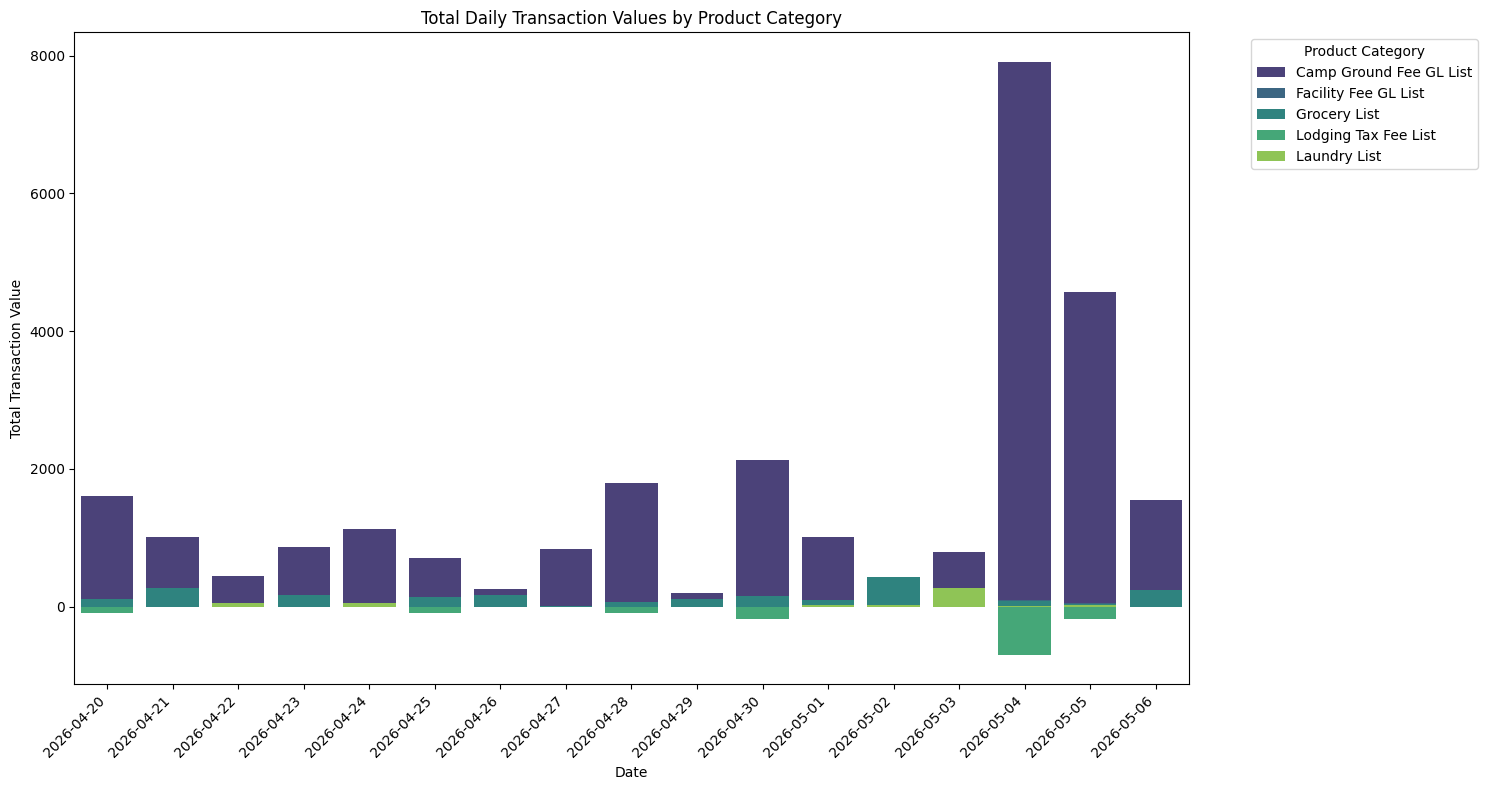

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate total transaction values by date and product_category
daily_category_txn_sum = daily_category_summary.groupby(['date', 'product_category'])['total_transaction_value'].sum().reset_index()

# Create a stacked bar plot
plt.figure(figsize=(15, 8))
sns.barplot(
    x='date',
    y='total_transaction_value',
    hue='product_category',
    data=daily_category_txn_sum,
    dodge=False, # This makes it a stacked bar chart
    palette='viridis'
)

plt.title('Total Daily Transaction Values by Product Category')
plt.xlabel('Date')
plt.ylabel('Total Transaction Value')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Product Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [22]:
output_excel_filename = "Tax_Calculation_Report.xlsx"

# Ensure the 'date' column is in the correct format for sorting
final_df['date'] = pd.to_datetime(final_df['date'], errors='coerce')

# Sort the final_df by date and reference for clear presentation
final_df_sorted = final_df.sort_values(by=['date', 'reference']).copy()

# Prepare the daily financial summary
daily_financial_summary = final_df_sorted.groupby(['date', 'product_category']).agg(
    total_transaction_value=('txn_line_total', 'sum'),
    total_lodging_sales=('lodging_total_sales', 'sum'),
    total_tax_5_percent=('tax_5_percent', 'sum'),
    total_tax_10_percent=('tax_10_percent', 'sum'),
    overall_order_total_txn=('txn_order_total', 'sum'),
    overall_order_total_lodging=('lodging_order_total', 'sum')
).reset_index()

# Add an overall daily total row to the financial summary
daily_totals = daily_financial_summary.groupby('date').sum(numeric_only=True).reset_index()
daily_totals['product_category'] = 'Daily Overall Total'
overall_financial_summary = pd.concat([daily_financial_summary, daily_totals]).sort_values(by=['date', 'product_category']).reset_index(drop=True)

with pd.ExcelWriter(output_excel_filename, engine='openpyxl') as writer:
    # Sheet 1: All detailed transactions, sorted by date
    final_df_sorted.to_excel(writer, sheet_name='All Transactions by Date', index=False)

    # Sheet 2: Daily financial summary by category with overall totals
    overall_financial_summary.to_excel(writer, sheet_name='Daily Financial Summary', index=False)

print(f"Data exported to {output_excel_filename}")


Data exported to Tax_Calculation_Report.xlsx


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

<div class="markdown-google-sans">

<a name="machine-learning-examples"></a>

### Featured examples

</div>

- [Train a miniGPT language model with JAX AI Stack](https://docs.jaxstack.ai/en/latest/JAX_for_LLM_pretraining.html)
- [LoRA/QLoRA finetuning for LLM using Tunix](https://github.com/google/tunix/blob/main/examples/qlora_gemma.ipynb)
- [Parameter-efficient fine-tuning of Gemma with LoRA and QLoRA](https://keras.io/examples/keras_recipes/parameter_efficient_finetuning_of_gemma_with_lora_and_qlora/)
- [Loading Hugging Face Transformers Checkpoints](https://keras.io/keras_hub/guides/hugging_face_keras_integration/)
- [8-bit Integer Quantization in Keras](https://keras.io/guides/int8_quantization_in_keras/)
- [Float8 training and inference with a simple Transformer model](https://keras.io/examples/keras_recipes/float8_training_and_inference_with_transformer/)
- [Pretraining a Transformer from scratch with KerasHub](https://keras.io/keras_hub/guides/transformer_pretraining/)
- [Simple MNIST convnet](https://keras.io/examples/vision/mnist_convnet/)
- [Image classification from scratch using Keras 3](https://keras.io/examples/vision/image_classification_from_scratch/)
- [Image Classification with KerasHub](https://keras.io/keras_hub/guides/classification_with_keras_hub/)
